In [89]:
import os
import warnings
import pandas as pd
pd.set_option('display.max_columns', None)
warnings.simplefilter(action='ignore', category=pd.errors.PerformanceWarning)
warnings.filterwarnings(action="ignore", message="credentials were not supplied. open data access only")
import tqdm

In [90]:
%load_ext autoreload
%autoreload 2
from socceraction.data.statsbomb import StatsBombLoader
import socceraction.spadl as spadl

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


### StatsBombLoader불러오기
Return a dataframe with both teams that participated in a game.

In [91]:
# datafolder = ".cache/joblib/statsbombpy/helpers/pluralize/" # Example of local folder with statsbomb data

SBL = StatsBombLoader(getter="remote", creds={"user": None, "passwd": None})
# SBL = StatsBombLoader(root=datafolder, getter="local")

In [92]:
competitions = SBL.competitions()
set(competitions.competition_name)

{'Champions League',
 "FA Women's Super League",
 'FIFA World Cup',
 'Indian Super league',
 'La Liga',
 'NWSL',
 'Premier League',
 'UEFA Euro',
 "UEFA Women's Euro",
 "Women's World Cup"}

In [93]:
games = pd.concat([
    SBL.games(row.competition_id, row.season_id)
    for row in SBL.competitions().itertuples()
])

#### 다양한 대회의 데이터가 기록되어 있음

#### 우리는 그 중에서 2018월드컵을 살펴봄(갑자기 2022년 월드컵기록도 나오기 시작해서 2018로만 따로 전처리함)
총 64개의 경기가 있었음

In [94]:
selected_competitions = competitions[(competitions.competition_name == "FIFA World Cup") & (competitions.season_name=='2018')]

games = pd.concat([
    SBL.games(row.competition_id, row.season_id)
    for row in selected_competitions.itertuples()
])

selected_competitions

,season_id,competition_id,competition_name,country_name,competition_gender,season_name
19,3,43,FIFA World Cup,International,male,2018


### 월드컵데이터를 따로 저장할 예정

그 전에 각 경기의 team, players의 정보 불러오기

In [95]:
games_verbose = tqdm.tqdm(list(games.itertuples()), desc="Loading game data")
teams, players = [], []
actions = {}
for game in games_verbose:
    # load data
    teams.append(SBL.teams(game.game_id))
    players.append(SBL.players(game.game_id))
    events = SBL.events(game.game_id)
    # convert data
    actions[game.game_id] = spadl.statsbomb.convert_to_actions(events, game.home_team_id)

teams = pd.concat(teams).drop_duplicates(subset="team_id")
players = pd.concat(players)

Loading game data: 100%|██████████| 64/64 [01:51<00:00,  1.74s/it]


In [99]:
datafolder = "../data-fifa"

# Create data folder if it doesn't exist
if not os.path.exists(datafolder):
    os.mkdir(datafolder)
    print(f"Directory {datafolder} created.")

spadl_h5 = os.path.join(datafolder, "spadl-statsbomb.h5")

# Store all spadl data in h5-file
with pd.HDFStore(spadl_h5) as spadlstore:
    spadlstore["competitions"] = competitions
    spadlstore["games"] = games
    spadlstore["teams"] = teams
    spadlstore["players"] = players[['player_id', 'player_name', 'nickname']].drop_duplicates(subset='player_id')
    spadlstore["player_games"] = players[['player_id', 'game_id', 'team_id', 'is_starter', 'starting_position_id', 'starting_position_name', 'minutes_played']]
    for game_id in actions.keys():
        spadlstore[f"actions/game_{game_id}"] = actions[game_id]

### 독일 VS 한국

0:2로 승리한 한국의 마지막 손흥민 골장면을 actions으로 정량화해서 데이터 불러오기

In [102]:
with pd.HDFStore(spadl_h5) as spadlstore:
    games = (
        spadlstore["games"]
        .merge(spadlstore["competitions"], how='left')
        .merge(spadlstore["teams"].add_prefix('home_'), how='left')
        .merge(spadlstore["teams"].add_prefix('away_'), how='left'))
    #Select korea vs germany game at World Cup
    game = games[(games.competition_name == "FIFA World Cup") 
                  & (games.away_team_name == "Germany")
                  & (games.home_team_name == "South Korea")]
    
    game_id = game.game_id.values[0]
    actions = (
        spadlstore[f"actions/game_{game_id}"]
        .merge(spadl.actiontypes_df(), how="left")
        .merge(spadl.results_df(), how="left")
        .merge(spadl.bodyparts_df(), how="left")
        .merge(spadlstore["players"], how="left")
        .merge(spadlstore["teams"], how="left")
    )

# use nickname if available else use full name
actions["player_name"] = actions[["nickname", "player_name"]].apply(lambda x: x[0] if x[0] else x[1], axis=1)
del actions['nickname']
actions

,game_id,original_event_id,period_id,time_seconds,team_id,player_id,start_x,start_y,end_x,end_y,type_id,result_id,bodypart_id,action_id,type_name,result_name,bodypart_name,player_name,team_name
0,7567,ee674161-e20e-42a3-a045-235673ba58c9,1,0.0,770,3496.0,52.058824,34.430380,62.647059,29.265823,0,1,4,0,pass,success,foot_left,Mesut Özil,Germany
1,7567,05876bde-9963-4494-b2a7-0f8e18f38ad4,1,1.0,770,5574.0,62.647059,29.265823,62.647059,29.265823,21,1,0,1,dribble,success,foot,Toni Kroos,Germany
2,7567,7b43d9ed-8e1e-4b4b-ba5a-acd49070b787,1,1.0,770,5574.0,62.647059,29.265823,54.705882,35.291139,0,1,5,2,pass,success,foot_right,Toni Kroos,Germany
3,7567,2a11a42d-e250-4150-bde9-6bdbc0164a9c,1,2.0,770,3496.0,54.705882,35.291139,57.352941,36.151899,21,1,0,3,dribble,success,foot,Mesut Özil,Germany
4,7567,91f09706-1eec-42f1-96cb-190ac7ae53f5,1,4.0,770,3496.0,57.352941,36.151899,73.235294,49.924051,0,1,4,4,pass,success,foot_left,Mesut Özil,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
2094,7567,1421b0b2-b073-4a36-8cbc-f0cadbaa1281,2,3218.0,770,5574.0,25.588235,24.101266,14.117647,18.936709,0,1,4,2094,pass,success,foot_left,Toni Kroos,Germany
2095,7567,f0005e62-648d-4d4e-a308-9ea657309c30,2,3218.0,770,5562.0,14.117647,18.936709,14.117647,19.797468,21,1,0,2095,dribble,success,foot,Thomas Müller,Germany
2096,7567,137b6f8d-c120-4477-b599-d0960c81fb4c,2,3220.0,770,5562.0,14.117647,19.797468,6.176471,31.848101,0,1,5,2096,pass,success,foot_right,Thomas Müller,Germany
2097,7567,60c04bc0-2d71-4bdd-9e54-a095419682a3,2,3221.0,770,5572.0,6.176471,32.708861,0.000000,30.987342,11,0,1,2097,shot,fail,head,Mats Hummels,Germany


2018-06-27 16:00:00 South Korea 2-0 Germany 96'


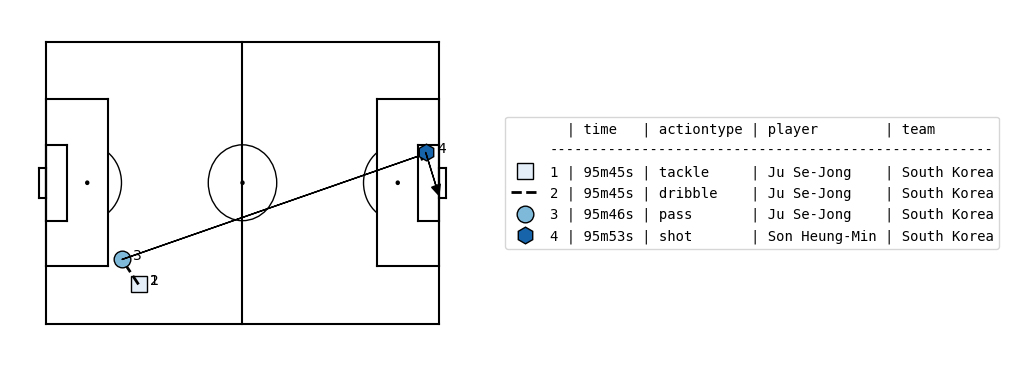

In [103]:
import matplotsoccer

# Select the 5 actions preceding the 2-0
shot = 2051
a = actions[shot-3:shot+1].copy()

# Print the game date and timestamp of the goal
g = game.iloc[0]
minute = int((a.period_id.values[0]-1) * 45 + a.time_seconds.values[0] // 60)
game_info = f"{g.game_date} {g.home_team_name} {g.home_score}-{g.away_score} {g.away_team_name} {minute + 1}'"
print(game_info)

# Plot the actions
def nice_time(row):
    minute = int((row.period_id-1)*45 +row.time_seconds // 60)
    second = int(row.time_seconds % 60)
    return f"{minute}m{second}s"

a["nice_time"] = a.apply(nice_time, axis=1)
labels = a[["nice_time", "type_name", "player_name", "team_name"]]

ax = matplotsoccer.actions(
    location=a[["start_x", "start_y", "end_x", "end_y"]],
    action_type=a.type_name,
    team= a.team_name,
    result= a.result_name == "success",
    label=labels,
    labeltitle=["time", "actiontype", "player", "team"],
    zoom=False,
    figsize=6
)